# Setup

In [15]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import numpy as np

In [16]:
from config.paths import SILVER_FACE_CLEAN, SILVER_PROCESSOS

sns.set_theme(style="whitegrid", context="notebook")

PATH_SENT = str(SILVER_PROCESSOS)
PATH_FACE = str(SILVER_FACE_CLEAN)

lf_sent = pl.scan_delta(PATH_SENT)
lf_face = pl.scan_delta(PATH_FACE)

# 1.

In [ ]:
overview = lf_sent.select(
    [
        pl.len().alias("n_decisoes"),
        pl.col("id_processo").n_unique().alias("n_processos_unicos"),
        pl.col("cd_processo").n_unique().alias("n_cd_unicos"),
        (pl.len() / pl.col("id_processo").n_unique()).alias(
            "decisoes_por_processo_media"
        ),
    ]
).collect()

print(overview)
# Completude das chaves jurídicas
nulls = lf_sent.select(
    [
        pl.col(c).null_count().alias(c)
        for c in [
            "id_processo",
            "classe",
            "assunto",
            "foro",
            "vara",
            "magistrado",
            "data_disponibilizacao",
            "decisao",
        ]
    ]
).collect()
print(nulls)

shape: (1, 4)
┌────────────┬────────────────────┬─────────────┬─────────────────────────────┐
│ n_decisoes ┆ n_processos_unicos ┆ n_cd_unicos ┆ decisoes_por_processo_media │
│ ---        ┆ ---                ┆ ---         ┆ ---                         │
│ u32        ┆ u32                ┆ u32         ┆ f64                         │
╞════════════╪════════════════════╪═════════════╪═════════════════════════════╡
│ 6430617    ┆ 5941254            ┆ 5941255     ┆ 1.082367                    │
└────────────┴────────────────────┴─────────────┴─────────────────────────────┘


# 2.

In [ ]:
def top_n(lf, col, n=15):
    return (
        lf.group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(n)
        .collect()
    )


for col in ["classe", "assunto", "comarca", "foro", "vara"]:
    print(f"\n=== Top {col} ===")
    display(top_n(lf_sent, col))


=== Top classe ===


classe,n
str,u32
"""Execução Fiscal""",6100561



=== Top assunto ===


assunto,n
str,u32
"""IPTU/ Imposto Predial e Territ…",2092880
"""Dívida Ativa""",1720485
"""Assunto não informado.""",653527
"""ISS/ Imposto sobre Serviços""",351661
"""ICMS/ Imposto sobre Circulação…",202801
…,…
"""Multas e demais Sanções""",81215
"""Taxas""",47485
"""Taxa de Coleta de Lixo""",33648



=== Top comarca ===


comarca,n
str,u32
"""SÃO PAULO""",384810
"""Guarulhos""",254029
"""Campinas""",182904
"""Praia Grande""",156067
"""Osasco""",148328
…,…
"""Piracicaba""",86912
"""Guarujá""",84574
"""São José do Rio Preto""",77364



=== Top foro ===


foro,n
str,u32
"""Foro das Execuções Fiscais Mun…",306917
"""Foro de Guarulhos""",254029
"""Foro de Campinas""",182904
"""Foro de Praia Grande""",156067
"""Foro de Osasco""",148328
…,…
"""Foro de Piracicaba""",86912
"""Foro de Guarujá""",84574
"""Foro de São José do Rio Preto""",77364



=== Top vara ===


vara,n
str,u32
"""SAF - Serviço de Anexo Fiscal""",1307050
"""Vara da Fazenda Pública""",961182
"""SEF - Setor de Execuções Fisca…",810625
"""Setor das Execuções Fiscais""",433701
"""Vara Única""",365926
…,…
"""SETOR DE EXECUÇÕES FISCAIS DA …",126544
"""2ª Vara""",115626
"""SEF - Setor das Execuções Fisc…",100471


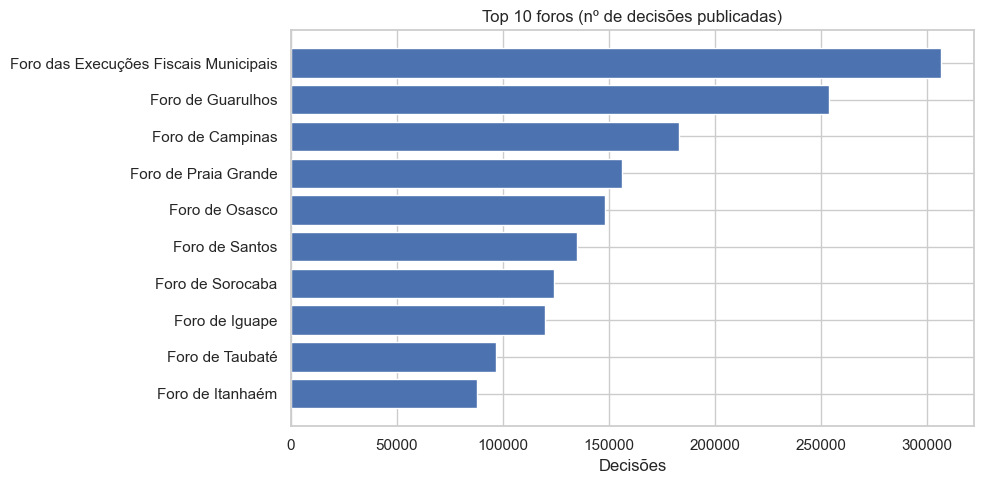

In [ ]:
top_foro = top_n(lf_sent, "foro", 10)
plt.figure(figsize=(10, 5))
plt.barh(top_foro["foro"][::-1], top_foro["n"][::-1])
plt.title("Top 10 foros (nº de decisões publicadas)")
plt.xlabel("Decisões")
plt.tight_layout()
plt.show()

# 3.

In [ ]:
lf_time = lf_sent.with_columns(
    pl.col("data_disponibilizacao")
    .str.strptime(pl.Date, "%d/%m/%Y", strict=False)
    .alias("dt_pub")
)

serie_mensal = (
    lf_time.filter(pl.col("dt_pub").is_not_null())
    .group_by(pl.col("dt_pub").dt.truncate("1mo").alias("mes"))
    .agg(pl.len().alias("n_decisoes"))
    .sort("mes")
    .collect()
)

(
    serie_mensal.plot.line(x="mes", y="n_decisoes").properties(
        title="Decisões publicadas por mês",
        width=800,
        height=400,
    )
)

alt.Chart(...)

In [ ]:
import json
from pathlib import Path

THRESHOLD = 25000

meses_baixo_volume = (
    serie_mensal.filter(pl.col("n_decisoes") < THRESHOLD)
    .sort("mes")
    .with_columns(
        pl.concat_str([pl.lit("01/"), pl.col("mes").dt.strftime("%m/%Y")]).alias(
            "inicio"
        ),
        pl.col("mes").dt.month_end().dt.strftime("%d/%m/%Y").alias("fim"),
    )
)

recollect_dates = [
    list(row) for row in meses_baixo_volume.select(["inicio", "fim"]).rows()
]

print(f"Meses com menos de {THRESHOLD} decisões: {len(recollect_dates)}")
with pl.Config(tbl_rows=50):
    display(meses_baixo_volume)

recollect_config = {"threshold": THRESHOLD, "ranges": recollect_dates}

# Preview JSON (same shape as scripts/data/recollect_dates.json)
print(json.dumps(recollect_config, indent=2, ensure_ascii=False)[:800])
if len(recollect_dates) > 5:
    print("...")

# Uncomment to overwrite the recollect queue:
out = Path("../../../pipelines/litigancia/scripts/data/recollect_dates.json").resolve()
out.write_text(
    json.dumps(recollect_config, indent=4, ensure_ascii=False) + "\n", encoding="utf-8"
)
print(f"Saved {len(recollect_dates)} ranges (threshold={THRESHOLD}) to {out}")


Meses com menos de 25000 decisões: 0


mes,n_decisoes,inicio,fim
date,u32,str,str


{
  "threshold": 25000,
  "ranges": []
}
Saved 0 ranges (threshold=25000) to /Users/etorebraga/Code/habitual-tax-debtor-research/scripts/data/recollect_dates.json


In [ ]:
por_ano = (
    lf_time.filter(pl.col("dt_pub").is_not_null())
    .group_by(pl.col("dt_pub").dt.year().alias("ano"))
    .agg(pl.len().alias("n"))
    .sort("ano")
    .collect()
)

(
    por_ano.plot.bar(
        x=alt.X("ano:Q", axis=alt.Axis(format="d", tickMinStep=1), title="Ano"),
        y="n",
    ).properties(
        title="Decisões publicadas por ano",
        width=800,
        height=400,
    )
)

alt.Chart(...)

# 4.

In [ ]:
tipo_ato = (
    lf_sent.with_columns(
        pl.col("decisao")
        .str.replace_all(r"\s+", " ")
        .str.extract(r"^([A-ZÁÉÍÓÚÃÕÇ\s]+)", 1)
        .str.strip_chars()
        .alias("tipo_ato")
    )
    .group_by("tipo_ato")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .head(20)
    .collect()
)

In [ ]:
with pl.Config(fmt_str_lengths=400):
    display(tipo_ato)

tipo_ato,n
str,u32
"""SENTENÇA P""",4644335
"""SENTENÇA""",375024
"""CONCLUSÃO E""",163009
"""C O N C L U S Ã O E""",120346
"""CONCLUSÃO""",105334
…,…
"""SENTENÇA DE EXTINÇÃO""",16853
"""S E N T E N Ç A P""",15805
"""SENTENÇA R""",13906


In [ ]:
stats_texto = (
    lf_sent.select(pl.col("decisao").str.len_chars().alias("chars"))
    .select(
        pl.col("chars").median().alias("mediana_chars"),
        pl.col("chars").quantile(0.95).alias("p95_chars"),
    )
    .collect()
)

display(stats_texto)

# 5.

In [ ]:
top_mag = (
    lf_sent.filter(pl.col("magistrado").is_not_null())
    .group_by("magistrado", "foro")
    .agg(pl.len().alias("n_decisoes"))
    .sort("n_decisoes", descending=True)
    .head(20)
    .collect()
)
display(top_mag)

magistrado,foro,n_decisoes
str,str,u32
"""Enoque Cartaxo de Souza""","""Foro de Praia Grande""",98767
"""FERNANDA SILVA GONCALVES""","""Foro de Campinas""",83756
"""Wander Pereira Rossette Júnior""","""Foro de Piracicaba""",67783
"""Cândido Alexandre Munhóz Pérez""","""Foro de Guarujá""",56997
"""GRACIELLA LORENZO SALZMAN""","""Foro de Barueri""",55453
…,…,…
"""Fernando de Arruda Silveira""","""Foro das Execuções Fiscais Mun…",39177
"""Fabio Francisco Taborda""","""Foro de São Vicente""",37928
"""André Mattos Soares""","""Foro de Diadema""",37815


# 6.

In [ ]:
# Filtro de sanidade (alinhado ao generate_plots_pge.ipynb)
TETO_VALOR = 1_000_000_000  # R$ 1 bi
ANO_MIN = 2000

lf_juri = lf_face.filter(pl.col("distribuicao_data").dt.year() >= ANO_MIN).filter(
    pl.col("valor_corrigido_atual").is_null()
    | (pl.col("valor_corrigido_atual") <= TETO_VALOR)
)

tramitacao = lf_juri.select(pl.col("tempo_tramitacao_meses").drop_nulls()).collect()[
    "tempo_tramitacao_meses"
]

tramitacao.describe()  # or tramitacao.quantile([0.25, 0.5, 0.75, 0.95])

statistic,value
str,f64
"""count""",1.493581e6
"""null_count""",0.0
"""mean""",61.223351
"""std""",59.149472
"""min""",-151.81
"""25%""",18.07
"""50%""",41.46
"""75%""",90.18
"""max""",312.52


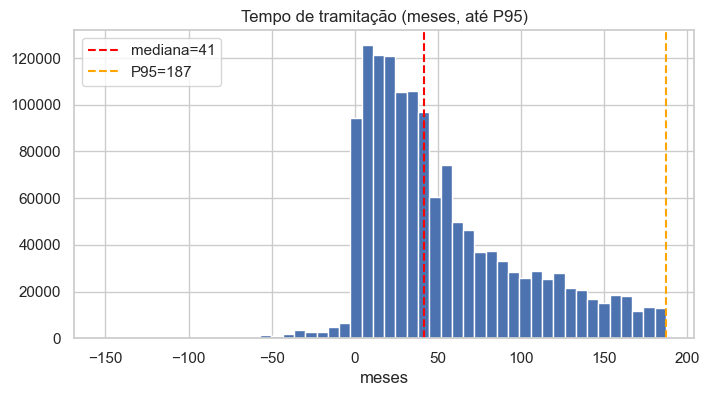

In [ ]:
# 6a — Distribuição de tramitação (meses), cap visual em P95
tramitacao.quantile([0.25, 0.5, 0.75, 0.95])
p95 = tramitacao.quantile(0.95)
tram_capped = tramitacao.filter(tramitacao <= p95)

plt.figure(figsize=(8, 4))
plt.hist(tram_capped.to_numpy(), bins=50)
plt.axvline(
    tramitacao.median(),
    color="red",
    linestyle="--",
    label=f"mediana={tramitacao.median():.0f}",
)
plt.axvline(p95, color="orange", linestyle="--", label=f"P95={p95:.0f}")
plt.title("Tempo de tramitação (meses, até P95)")
plt.xlabel("meses")
plt.legend()
plt.show()

In [ ]:
# 6b — Tipo de sentença
tipo_sent = (
    lf_juri.group_by("tipo_sentença")
    .len()
    .sort("len", descending=True)
    .head(15)
    .collect()
)
display(tipo_sent)

tipo_sentença,len
str,u32
"""[""Extinta a Execução/Cumprimen…",673123
"""[""Extinto o Processo sem Resol…",104541
"""[""Extinto o Processo sem Resol…",90239
"""[""Declarada Decadência ou Pres…",87831
"""[""Extinta a Punibilidade por P…",64735
…,…
"""[null]""",23789
"""[""Declarada Decadência ou Pres…",17344
"""[""Extinta a Execução pela Pres…",15940


In [ ]:
(
    tipo_sent.plot.bar(
        x=alt.X("len:Q", title="Processos"),
        y=alt.Y("tipo_sentença:N", sort="-x", title=None),
    ).properties(title="Top 15 tipos de sentença", width=700, height=400)
)

alt.Chart(...)

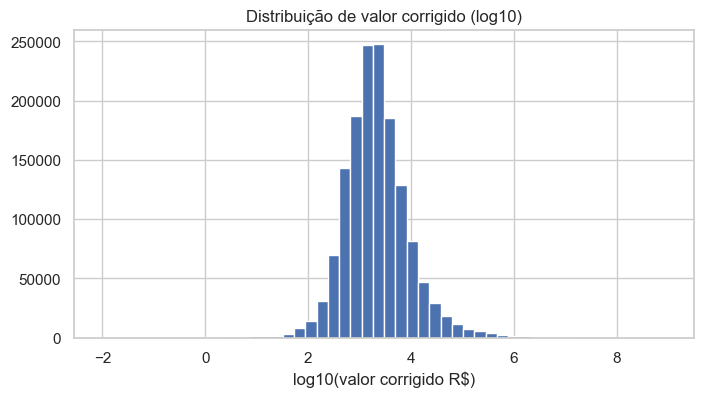

mediana: 1,942.56  IQR: [875.57, 4,528.54]  n=1,482,828


In [ ]:
# 6c — Valor corrigido (log scale; use mediana + IQR, not só média)
vals = (
    lf_juri.filter(pl.col("valor_corrigido_atual") > 0)
    .select("valor_corrigido_atual")
    .collect()["valor_corrigido_atual"]
)
log_vals = np.log10(vals.to_numpy())
plt.figure(figsize=(8, 4))
plt.hist(log_vals, bins=50)
plt.xlabel("log10(valor corrigido R$)")
plt.title("Distribuição de valor corrigido (log10)")
plt.show()
# Robust summary (better than mean/std for heavy tails)
q1, med, q3 = vals.quantile(0.25), vals.median(), vals.quantile(0.75)
print(f"mediana: {med:,.2f}  IQR: [{q1:,.2f}, {q3:,.2f}]  n={len(vals):,}")

# 7.

In [ ]:
cds_sent = lf_sent.select(pl.col("cd_processo").unique())
cds_face = lf_face.select(pl.col("cd_processo").unique())
n_sent = cds_sent.collect().height
n_com_face = cds_sent.join(cds_face, on="cd_processo", how="inner").collect().height
n_so_sent = cds_sent.join(cds_face, on="cd_processo", how="anti").collect().height
n_so_face = cds_face.join(cds_sent, on="cd_processo", how="anti").collect().height
cobertura = pl.DataFrame(
    {
        "cds_em_sentencas": [n_sent],
        "cds_com_face": [n_com_face],
        "cds_so_sent": [n_so_sent],
        "cds_so_face": [n_so_face],
    }
).with_columns(
    (pl.col("cds_com_face") / pl.col("cds_em_sentencas") * 100)
    .round(2)
    .alias("pct_cobertura_face")
)
display(cobertura)

cds_em_sentencas,cds_com_face,cds_so_sent,cds_so_face,pct_cobertura_face
i64,i64,i64,i64,f64
4420009,1558735,2861274,112,35.27


# EDA Case Header Extracted

In [ ]:
# lf_face = pl.scan_delta(PATH_FACE) já definido no Setup (lazy, não materializa tudo)
lf_silver_face = lf_face

n_processos = lf_silver_face.select(pl.len()).collect().item()
print(f"silver face rows: {n_processos:,}")

silver face rows: 5,812,239


In [ ]:
# Evita colunas JSON gigantes no preview
HEAVY_FACE_COLS = ["movimentações", "tipo_sentença", "data_sentença"]

lf_silver_face.drop(HEAVY_FACE_COLS).head(5).collect()

numero,classe,assunto,foro,vara,distribuicao,controle,area,valor,outros_assuntos,autores,advogados_autores,reus,advogados_reus,cd_processo,url_scraped,ingested_at,num_processo_limpo,distribuicao_data,valor_limpo,data_sentenca_clean,tempo_tramitacao_meses,valor_corrigido_atual,valor_sm,updated_at,fator_correcao_ipca
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,"datetime[μs, UTC]",str,datetime[μs],f64,datetime[μs],f64,f64,f64,"datetime[μs, UTC]",f64
"""1563599-98.2016.8.26.0090""","""Execução Fiscal""","""IPTU/ Imposto Predial e Territ…","""Foro das Execuções Fiscais Mun…","""Vara das Execuções Fiscais Mun…","""28/06/2016 às 17:51 - Livre""","""2016/065469""","""Cível""","""R$ 1.474,35""","""Cível""","""PREFEITURA MUNICIPAL DE SÃO PA…","""NÃO HÁ REGISTRO""","""Maria Leonor Ferreira de Barro…","""NÃO HÁ REGISTRO""","""2I00082VP0000""","""https://esaj.tjsp.jus.br/cpopg…",2026-06-20 18:55:49.221143 UTC,"""15635999820168260090""",2016-06-28 00:00:00,1474.35,2022-03-28 00:00:00,68.96,2409.33,1.48,2026-06-24 00:45:18.941110 UTC,1.634166
"""1563606-90.2016.8.26.0090""","""Execução Fiscal""","""IPTU/ Imposto Predial e Territ…","""Foro das Execuções Fiscais Mun…","""Vara das Execuções Fiscais Mun…","""28/06/2016 às 17:52 - Livre""","""2016/065476""","""Cível""","""R$ 3.509,77""","""Cível""","""PREFEITURA MUNICIPAL DE SÃO PA…","""NÃO HÁ REGISTRO""","""Maria Leonor Ferreira de Barro…","""NÃO HÁ REGISTRO""","""2I00082VW0000""","""https://esaj.tjsp.jus.br/cpopg…",2026-06-20 18:55:49.238017 UTC,"""15636069020168260090""",2016-06-28 00:00:00,3509.77,2022-03-29 00:00:00,68.99,5735.55,3.53,2026-06-24 00:45:18.941110 UTC,1.634166
"""1563594-76.2016.8.26.0090""","""Execução Fiscal""","""IPTU/ Imposto Predial e Territ…","""Foro das Execuções Fiscais Mun…","""Vara das Execuções Fiscais Mun…","""28/06/2016 às 17:51 - Livre""","""2016/065464""","""Cível""","""R$ 1.630,90""","""Cível""","""PREFEITURA MUNICIPAL DE SÃO PA…","""NÃO HÁ REGISTRO""","""Maria Leonor Ferreira de Barro…","""NÃO HÁ REGISTRO""","""2I00082VK0000""","""https://esaj.tjsp.jus.br/cpopg…",2026-06-20 18:55:49.257609 UTC,"""15635947620168260090""",2016-06-28 00:00:00,1630.9,2022-03-25 00:00:00,68.86,2665.16,1.64,2026-06-24 00:45:18.941110 UTC,1.634166
"""1563588-69.2016.8.26.0090""","""Execução Fiscal""","""IPTU/ Imposto Predial e Territ…","""Foro das Execuções Fiscais Mun…","""Vara das Execuções Fiscais Mun…","""28/06/2016 às 17:50 - Livre""","""2016/065458""","""Cível""","""R$ 1.786,98""","""Cível""","""PREFEITURA MUNICIPAL DE SÃO PA…","""NÃO HÁ REGISTRO""","""Maria Ferreira de Barros do Am…","""NÃO HÁ REGISTRO""","""2I00082VE0000""","""https://esaj.tjsp.jus.br/cpopg…",2026-06-20 18:55:49.280129 UTC,"""15635886920168260090""",2016-06-28 00:00:00,1786.98,2022-03-28 00:00:00,68.96,2920.22,1.8,2026-06-24 00:45:18.941110 UTC,1.634166
"""1563610-30.2016.8.26.0090""","""Execução Fiscal""","""IPTU/ Imposto Predial e Territ…","""Foro das Execuções Fiscais Mun…","""Vara das Execuções Fiscais Mun…","""28/06/2016 às 17:53 - Livre""","""2016/065480""","""Cível""","""R$ 5.246,07""","""Cível""","""PREFEITURA MUNICIPAL DE SÃO PA…","""NÃO HÁ REGISTRO""","""Maria Leonor Ferreira de Barro…","""NÃO HÁ REGISTRO""","""2I00082W00000""","""https://esaj.tjsp.jus.br/cpopg…",2026-06-20 18:55:49.296746 UTC,"""15636103020168260090""",2016-06-28 00:00:00,5246.07,2022-03-28 00:00:00,68.96,8572.95,5.28,2026-06-24 00:45:18.941110 UTC,1.634166


In [ ]:
lf_silver_face.collect_schema().names()

['numero',
 'classe',
 'assunto',
 'foro',
 'vara',
 'distribuicao',
 'controle',
 'area',
 'valor',
 'outros_assuntos',
 'autores',
 'advogados_autores',
 'reus',
 'advogados_reus',
 'movimentações',
 'tipo_sentença',
 'data_sentença',
 'cd_processo',
 'url_scraped',
 'ingested_at',
 'num_processo_limpo',
 'distribuicao_data',
 'valor_limpo',
 'data_sentenca_clean',
 'tempo_tramitacao_meses',
 'valor_corrigido_atual',
 'valor_sm',
 'updated_at',
 'fator_correcao_ipca']

In [ ]:
NUMERIC_FACE_COLS = [
    "valor_limpo",
    "tempo_tramitacao_meses",
    "valor_corrigido_atual",
    "valor_sm",
    "fator_correcao_ipca",
]

lf_silver_face.select(NUMERIC_FACE_COLS).describe()

statistic,valor_limpo,tempo_tramitacao_meses,valor_corrigido_atual,valor_sm,fator_correcao_ipca
str,f64,f64,f64,f64,f64
"""count""",5.632723e6,5.725135e6,5.632723e6,5.632723e6,5.812239e6
"""null_count""",179516.0,87104.0,179516.0,179516.0,0.0
"""mean""",1.6830e6,74.026368,7.4771e6,4606.990381,1.964117
"""std""",3.4129e9,75.835018,1.5271e10,9.4091e6,0.993877
"""min""",0.01,-455.81,0.01,0.0,1.0
"""25%""",521.48,18.36,935.51,0.58,1.417005
"""50%""",1169.25,47.93,2024.67,1.25,1.573721
"""75%""",2740.08,109.13,4731.34,2.92,2.232145
"""max""",8.0600e12,1060.28,3.6069e13,2.2223e10,7.516555


## CASE 1 - Overview

In [ ]:
overview_case = lf_silver_face.select(
    [
        pl.len().alias("n_processos"),
        pl.col("cd_processo").n_unique().alias("n_cd_unicos"),
        pl.col("numero").n_unique().alias("n_numero_unicos"),
    ]
).collect()

print("=== CASE overview ===")
display(overview_case)

case_key_cols = [
    "classe",
    "assunto",
    "foro",
    "vara",
    "distribuicao_data",
    "valor_corrigido_atual",
]

case_nulls = lf_silver_face.select(
    [pl.col(c).null_count().alias(c) for c in case_key_cols]
).collect()

print("=== CASE nulls ===")
display(case_nulls)

=== CASE overview ===


n_processos,n_cd_unicos,n_numero_unicos
u32,u32,u32
5812239,5812239,5811868


=== CASE nulls ===


classe,assunto,foro,vara,distribuicao_data,valor_corrigido_atual
u32,u32,u32,u32,u32,u32
0,0,0,0,341,179516


## CASE 2 - Dimensões categóricas

In [ ]:
for col in ["classe", "assunto", "foro", "vara"]:
    print(f"\n=== CASE Top {col} ===")
    display(top_n(lf_silver_face, col))


=== CASE Top classe ===


classe,n
str,u32
"""Execução Fiscal""",5811850
"""NÃO HÁ REGISTRO""",332
"""""",9
"""Embargos à Execução Fiscal""",7
"""Execução de Pena de Multa""",6
…,…
"""Execução Fiscal (0023447-85.20…",1
"""Execução Fiscal (1000003-55.19…",1
"""Execução Fiscal (0006526-27.20…",1



=== CASE Top assunto ===


assunto,n
str,u32
"""IPTU/ Imposto Predial e Territ…",2016395
"""Dívida Ativa""",1631853
"""NÃO HÁ REGISTRO""",596917
"""ISS/ Imposto sobre Serviços""",340020
"""ICMS/ Imposto sobre Circulação…",196435
…,…
"""Multas e demais Sanções""",79285
"""Taxas""",45444
"""Taxa de Coleta de Lixo""",32798



=== CASE Top foro ===


foro,n
str,u32
"""Foro das Execuções Fiscais Mun…",300909
"""Foro de Guarulhos""",247809
"""Foro de Campinas""",178379
"""Foro de Praia Grande""",150369
"""Foro de Osasco""",140528
…,…
"""Foro de Guarujá""",82925
"""Foro de Piracicaba""",77707
"""Foro de São José do Rio Preto""",75379



=== CASE Top vara ===


vara,n
str,u32
"""SAF - Serviço de Anexo Fiscal""",1231806
"""Vara da Fazenda Pública""",923699
"""SEF - Setor de Execuções Fisca…",764666
"""Setor das Execuções Fiscais""",398339
"""Vara Única""",343506
…,…
"""SETOR DE EXECUÇÕES FISCAIS DA …",122319
"""2ª Vara""",108439
"""SEF - Setor das Execuções Fisc…",94484


## CASE - Tributos estaduais (IPVA, ITCMD/ITCD, ICMS)

No banco CASE, não há assunto literal começando com `ITCMD`; a contagem abaixo usa `ITCD - Imposto de Transmissão Causa Mortis...` como equivalente operacional de ITCMD.

In [ ]:
def mask_tributo_case(assunto: pl.Expr, tributo: str) -> pl.Expr:
    if tributo == "ITCMD":
        return assunto.str.starts_with("ITCD") | assunto.str.starts_with("ITCMD")

    return (
        assunto.str.starts_with(f"{tributo}/")
        | assunto.str.starts_with(f"{tributo} -")
        | assunto.str.starts_with(f"{tributo} /")
        | (assunto == tributo)
    )


TRIBUTOS_CASE = ["IPVA", "ITCMD", "ICMS"]
assunto_case = pl.col("assunto")

tributos_case_rows = []
tributos_case_mask = pl.lit(False)

for tributo in TRIBUTOS_CASE:
    mask = mask_tributo_case(assunto_case, tributo)
    tributos_case_mask = tributos_case_mask | mask

    counts = (
        lf_silver_face.filter(mask)
        .select(
            pl.len().alias("n_processos"),
            pl.col("cd_processo").n_unique().alias("n_cd_unicos"),
        )
        .collect()
    )

    tributos_case_rows.append(
        {
            "tributo": tributo,
            "n_processos": counts["n_processos"][0],
            "n_cd_unicos": counts["n_cd_unicos"][0],
        }
    )

tributos_case_breakdown = pl.DataFrame(tributos_case_rows)
tributos_case_total = (
    lf_silver_face.filter(tributos_case_mask)
    .select(
        pl.len().alias("n_processos"),
        pl.col("cd_processo").n_unique().alias("n_cd_unicos"),
    )
    .collect()
)

print("=== CASE IPVA + ITCMD (ITCD) + ICMS ===")
display(tributos_case_breakdown)
display(tributos_case_total)

print(
    "Total de processos CASE em IPVA + ITCMD (ITCD) + ICMS: "
    f"{tributos_case_total['n_cd_unicos'][0]:,}"
)

=== CASE IPVA + ITCMD (ITCD) + ICMS ===


tributo,n_processos,n_cd_unicos
str,i64,i64
"""IPVA""",144585,144585
"""ITCMD""",2506,2506
"""ICMS""",199822,199822


n_processos,n_cd_unicos
u32,u32
346913,346913


Total de processos CASE em IPVA + ITCMD (ITCD) + ICMS: 346,913


## CASE 3 - Distribuição por ano

In [ ]:
por_ano_case = (
    lf_silver_face.filter(pl.col("distribuicao_data").is_not_null())
    .group_by(pl.col("distribuicao_data").dt.year().alias("ano"))
    .agg(pl.len().alias("n_processos"))
    .sort("ano")
    .collect()
)

display(por_ano_case)

(
    por_ano_case.plot.bar(
        x=alt.X("ano:Q", axis=alt.Axis(format="d", tickMinStep=1), title="Ano"),
        y=alt.Y("n_processos:Q", title="Processos"),
    ).properties(
        title="CASE: processos por ano de distribuição",
        width=800,
        height=400,
    )
)

ano,n_processos
i32,u32
1934,1
1935,1
1936,38
1937,55
1938,9
…,…
2022,326654
2023,249085
2024,111554


alt.Chart(...)